In [188]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

# 1. Data Collection

In [189]:
now = datetime.now()

start = datetime(now.year-10, now.month, now.day)
end=now
ticker = 'AAPL'
df = yf.download(ticker, start, end)
df

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-08-11,23.817499,24.020000,23.709999,23.997499,21.332218,146340000
2014-08-12,24.010000,24.219999,23.902500,23.992500,21.327774,135180000
2014-08-13,24.037500,24.309999,24.010000,24.309999,21.610010,127664000
2014-08-14,24.332500,24.392500,24.200001,24.375000,21.667791,112464000
2014-08-15,24.475000,24.547501,24.215000,24.495001,21.774471,195804000
...,...,...,...,...,...,...
2024-08-05,199.089996,213.500000,196.000000,209.270004,209.270004,119548600
2024-08-06,205.300003,209.990005,201.070007,207.229996,207.229996,69660500
2024-08-07,206.899994,213.639999,206.389999,209.820007,209.820007,63516400


In [190]:
df.tail()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-08-05,199.089996,213.500000,196.000000,209.270004,209.270004,119548600
2024-08-06,205.300003,209.990005,201.070007,207.229996,207.229996,69660500
2024-08-07,206.899994,213.639999,206.389999,209.820007,209.820007,63516400
2024-08-08,213.110001,214.199997,208.830002,213.309998,213.309998,47161100
2024-08-09,212.100006,216.779999,211.970001,216.240005,216.240005,42171700


# 2. Data Exploration & Visualization

In [191]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [192]:
df.shape

(2517, 6)

In [193]:
df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-08-11,23.817499,24.020000,23.709999,23.997499,21.332218,146340000
2014-08-12,24.010000,24.219999,23.902500,23.992500,21.327774,135180000
2014-08-13,24.037500,24.309999,24.010000,24.309999,21.610010,127664000
2014-08-14,24.332500,24.392500,24.200001,24.375000,21.667791,112464000
2014-08-15,24.475000,24.547501,24.215000,24.495001,21.774471,195804000
...,...,...,...,...,...,...
2024-08-05,199.089996,213.500000,196.000000,209.270004,209.270004,119548600
2024-08-06,205.300003,209.990005,201.070007,207.229996,207.229996,69660500
2024-08-07,206.899994,213.639999,206.389999,209.820007,209.820007,63516400


In [194]:
df.isna().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [195]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2517.000000,2517.000000,2517.000000,2517.000000,2517.000000,2.517000e+03
mean,88.191078,89.146239,87.297605,88.261588,86.265451,1.238499e+08
std,60.447253,61.113455,59.832905,60.500224,61.012333,7.170111e+07
min,22.500000,22.917500,22.367500,22.584999,20.744022,2.404830e+07
25%,33.212502,33.282501,32.805000,33.134998,30.639999,7.548600e+07
50%,55.000000,55.622501,54.320000,55.007500,52.777889,1.048792e+08
75%,147.070007,148.880005,145.649994,147.070007,145.431900,1.511010e+08
max,236.479996,237.229996,233.089996,234.820007,234.820007,7.593852e+08


In [196]:
df.dtypes

Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

In [197]:
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-08-11,23.817499,24.020000,23.709999,23.997499,21.332218,146340000
2014-08-12,24.010000,24.219999,23.902500,23.992500,21.327774,135180000
2014-08-13,24.037500,24.309999,24.010000,24.309999,21.610010,127664000
2014-08-14,24.332500,24.392500,24.200001,24.375000,21.667791,112464000
2014-08-15,24.475000,24.547501,24.215000,24.495001,21.774471,195804000


In [198]:
df = df.reset_index()
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-08-11,23.817499,24.020000,23.709999,23.997499,21.332218,146340000
1,2014-08-12,24.010000,24.219999,23.902500,23.992500,21.327774,135180000
2,2014-08-13,24.037500,24.309999,24.010000,24.309999,21.610010,127664000
3,2014-08-14,24.332500,24.392500,24.200001,24.375000,21.667791,112464000
4,2014-08-15,24.475000,24.547501,24.215000,24.495001,21.774471,195804000


Text(0.5, 1.0, 'AAPL')

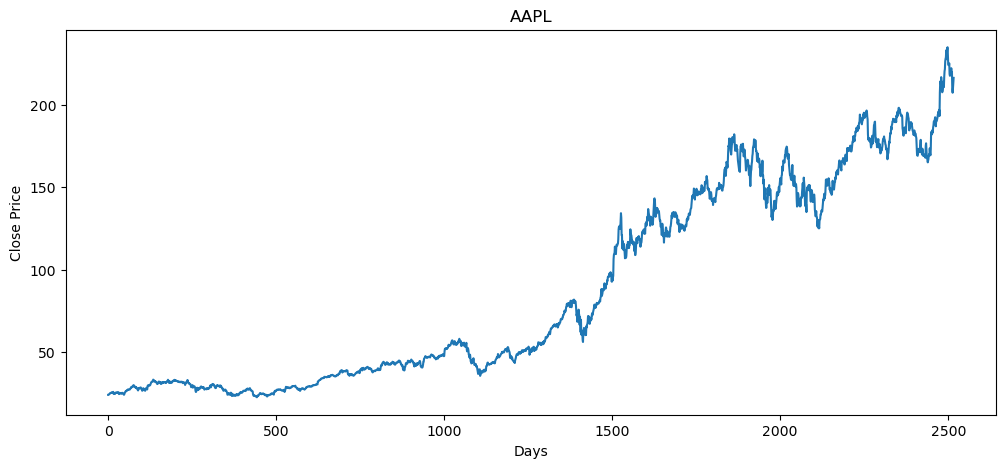

In [199]:
plt.figure(figsize = (12,5))
plt.plot(df.Close)
plt.xlabel('Days')
plt.ylabel('Close Price')
plt.title(ticker)

# 3. Feature Engineering

In [200]:
temp_data = [10, 15, 20, 18, 30, 22, 25, 32, 35, 38]
print(sum(temp_data[1:6])/5)

21.0


In [201]:
df1 = pd.DataFrame([10, 15, 20, 18, 30, 22, 25, 32, 35, 38])
df1

,0
0,10
1,15
2,20
3,18
4,30
5,22
6,25
7,32
8,35
9,38


In [202]:
df1['MA_5'] = df1.rolling(5).mean() # moving average with the window size of 5
df1

,0,MA_5
0,10,NaN
1,15,NaN
2,20,NaN
3,18,NaN
4,30,18.6
5,22,21.0
6,25,23.0
7,32,25.4
8,35,28.8
9,38,30.4


#### 100 days moving average

In [203]:
df['MA_100'] = df.Close.rolling(100).mean()

In [204]:
df['MA_100'].head(103)

0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
         ...    
98           NaN
99     26.430575
100    26.463925
101    26.489625
102    26.512175
Name: MA_100, Length: 103, dtype: float64

Text(0.5, 1.0, '100 Days Moving Average')

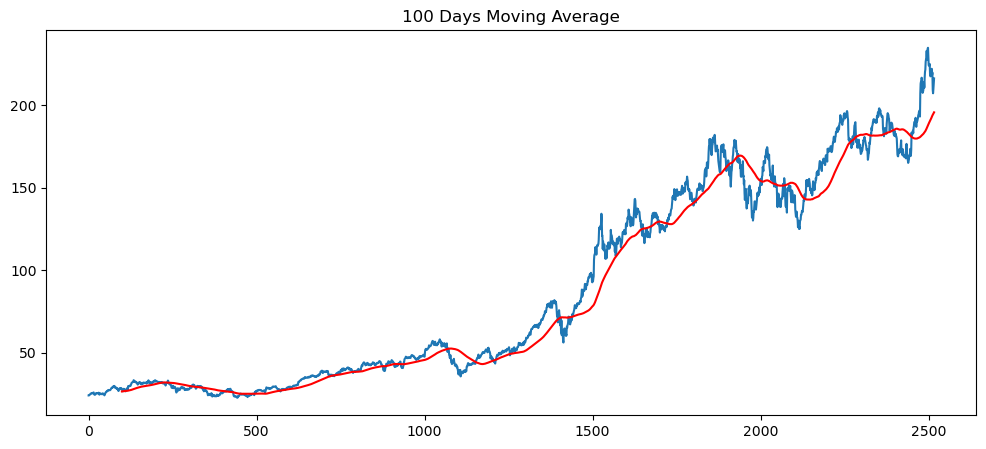

In [205]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r') # 'r' for red color
plt.title('100 Days Moving Average')

#### 200 days moving average

In [206]:
df['MA_200'] = df.Close.rolling(200).mean()
df['MA_200']

0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
          ...    
2512    189.68215
2513    189.83910
2514    190.01090
2515    190.21305
2516    190.42925
Name: MA_200, Length: 2517, dtype: float64

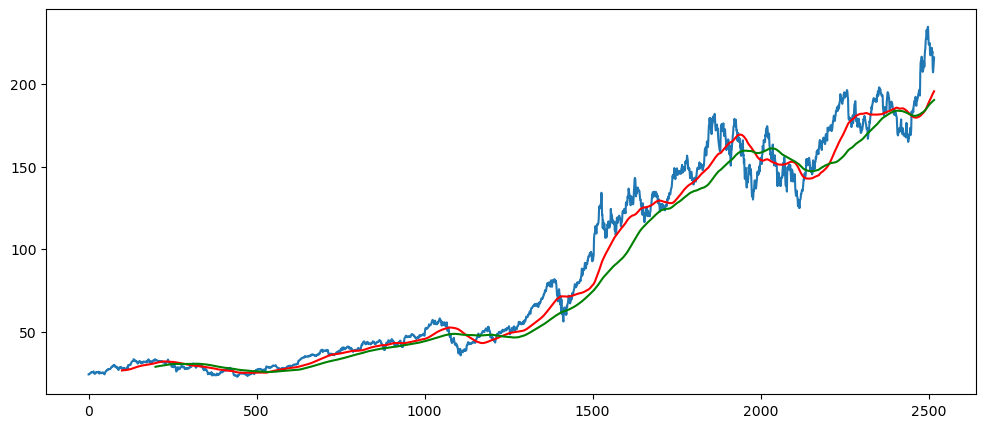

In [207]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r') # 'r' for red color
plt.plot(df['MA_200'], 'g') # 'r' for red color

#### Calculating % changed in each trading session

In [208]:
df['Percentage Changed'] = df.Close.pct_change()
df[['Close', 'Percentage Changed']]

,Close,Percentage Changed
0,23.997499,NaN
1,23.992500,-0.000208
2,24.309999,0.013233
3,24.375000,0.002674
4,24.495001,0.004923
...,...,...
2512,209.270004,-0.048167
2513,207.229996,-0.009748
2514,209.820007,0.012498
2515,213.309998,0.016633


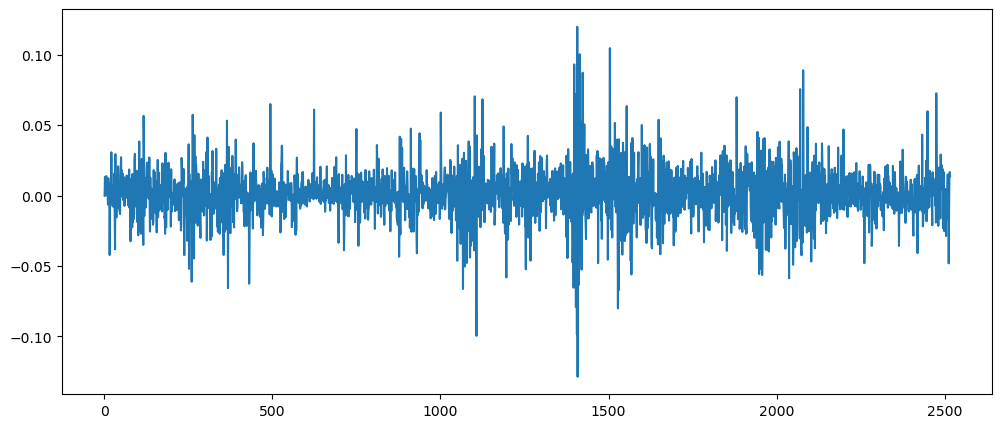

In [209]:
plt.figure(figsize=(12, 5))
plt.plot(df['Percentage Changed'])

# 4. Data Preprocessing

In [210]:
df.shape

(2517, 10)

In [211]:
df

,Date,Open,High,Low,Close,Adj Close,Volume,MA_100,MA_200,Percentage Changed
0,2014-08-11,23.817499,24.020000,23.709999,23.997499,21.332218,146340000,NaN,NaN,NaN
1,2014-08-12,24.010000,24.219999,23.902500,23.992500,21.327774,135180000,NaN,NaN,-0.000208
2,2014-08-13,24.037500,24.309999,24.010000,24.309999,21.610010,127664000,NaN,NaN,0.013233
3,2014-08-14,24.332500,24.392500,24.200001,24.375000,21.667791,112464000,NaN,NaN,0.002674
4,2014-08-15,24.475000,24.547501,24.215000,24.495001,21.774471,195804000,NaN,NaN,0.004923
...,...,...,...,...,...,...,...,...,...,...
2512,2024-08-05,199.089996,213.500000,196.000000,209.270004,209.270004,119548600,194.1147,189.68215,-0.048167
2513,2024-08-06,205.300003,209.990005,201.070007,207.229996,207.229996,69660500,194.4757,189.83910,-0.009748
2514,2024-08-07,206.899994,213.639999,206.389999,209.820007,209.820007,63516400,194.8439,190.01090,0.012498
2515,2024-08-08,213.110001,214.199997,208.830002,213.309998,213.309998,47161100,195.2508,190.21305,0.016633


In [212]:
# Splitting data into Training and Testing
data_training = pd.DataFrame(df.Close[0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df.Close[int(len(df)*0.70): int(len(df))])

print(data_training.shape)
print(data_testing.shape)

(1761, 1)
(756, 1)


In [213]:
data_training.head()

,Close
0,23.997499
1,23.992500
2,24.309999
3,24.375000
4,24.495001


In [214]:
data_testing.head()

,Close
1761,146.089996
1762,145.600006
1763,145.860001
1764,148.889999
1765,149.100006


In [215]:
data_training

,Close
0,23.997499
1,23.992500
2,24.309999
3,24.375000
4,24.495001
...,...
1756,145.520004
1757,147.360001
1758,146.949997
1759,147.059998


In [216]:
# Scaling down the data between 0 and 1
# For the LSTM models, we have to scale down the data, we cannot just provide this data as it is,
# we need to kind of normalize the data between 0 and 1

In [217]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [218]:
# Now we will have to fit this data to the MinMaxScaler

In [219]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.01116028],
       [0.01112078],
       [0.01362936],
       ...,
       [0.98261765],
       [0.98348677],
       [0.9762178 ]])

In [220]:
data_training_array.shape

(1761, 1)

In [221]:
type(data_training_array)

numpy.ndarray

# 5. Sequence Creation

In [222]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i, 0])
    print(data_training_array[i-100: i])
    
x_train, y_train = np.array(x_train), np.array(y_train)

[[0.01116028]
 [0.01112078]
 [0.01362936]
 [0.01414294]
 [0.01509107]
 [0.01742189]
 [0.020128  ]
 [0.02020702]
 [0.02022677]
 [0.02168847]
 [0.02212303]
 [0.0208391 ]
 [0.02328843]
 [0.02352547]
 [0.02401929]
 [0.02559951]
 [0.01698733]
 [0.01536761]
 [0.01704659]
 [0.01584167]
 [0.01511082]
 [0.02105638]
 [0.02190575]
 [0.02236007]
 [0.0223008 ]
 [0.02077985]
 [0.02220204]
 [0.02261685]
 [0.02097737]
 [0.02117489]
 [0.02429582]
 [0.02253783]
 [0.01487379]
 [0.02056256]
 [0.01929839]
 [0.02056256]
 [0.01746139]
 [0.01888359]
 [0.01833052]
 [0.01833052]
 [0.01661203]
 [0.02066133]
 [0.02109588]
 [0.02052307]
 [0.01870581]
 [0.01661203]
 [0.01422195]
 [0.01169361]
 [0.01447873]
 [0.01860705]
 [0.02396003]
 [0.02498716]
 [0.02862167]
 [0.02939202]
 [0.02917474]
 [0.03239443]
 [0.03357958]
 [0.0328685 ]
 [0.03488327]
 [0.03764865]
 [0.03606843]
 [0.036582  ]
 [0.03626595]
 [0.0368783 ]
 [0.03652275]
 [0.03824122]
 [0.0413029 ]
 [0.04440407]
 [0.04709044]
 [0.04671513]
 [0.04963854]
 [0.04

In [223]:
y_train

array([0.03751038, 0.03142655, 0.03144631, ..., 0.98261765, 0.98348677,
       0.9762178 ])

In [224]:
x_train.shape

(1661, 100, 1)

In [225]:
x_train.ndim

3

# 6. Model Building

In [226]:
import tensorflow as tf
print(tf.__version__)

2.17.0


In [227]:
# ML Model
from keras.layers import Dense, LSTM, Input
from keras.models import Sequential

In [228]:
# model = Sequential()
# model.add(LSTM(units=50, activation='relu', return_sequences=True, 
#               input_shape=(x_train.shape[1], 1)))
# model.add(Dropout(0.2))


# model.add(LSTM(units=60, activation='relu', return_sequences=True))
# model.add(Dropout(0.3))


# model.add(LSTM(units=80, activation='relu', return_sequences=True))
# model.add(Dropout(0.4))


# model.add(LSTM(units=120, activation='relu'))
# model.add(Dropout(0.5))


# model.add(Dense(units=1))

In [229]:
model = Sequential()

# Input layer defines the shape of the data the model will receive
# (100, 1) means each input sample is a sequence of 100 time steps, 
# with 1 feature at each time step (e.g., stock closing price)
model.add(Input(shape=(100, 1)))

# First LSTM layer with 128 units, tanh activation function. Tann means Hyperbolic Tangent, this helps the network handle
# both positive and negative values, which is important when you're trying to capture patterns in sequential data.
# We also set return_sequences=True because we want this layer to return the full sequence to the next LSTM layer.
# For example, if you have a sequence of 100 time steps, and you set return_sequences=True, the LSTM layer will produce 
# an output for each of those 100 steps
model.add(LSTM(units=128, activation='tanh', return_sequences=True))

# No return_sequences means this layer outputs a single value summarizing the sequence
# Now at this point, we got the single value summarizing the sequence of output that was generated in the previous layer
model.add(LSTM(units=64))

# A Dense layer is a fully connected layer, meaning that each neuron in the layer is connected to every neuron in the previous layer. 
# These layers are typically used at the end of a neural network to transform the learned features into the final output.
model.add(Dense(25))
model.add(Dense(1))

# 7. Model Training

In [230]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 0.0159
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 5.0885e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 4.9382e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 5.6064e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 4.0526e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 4.2494e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 3.6701e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 3.5526e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 4.0052e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 4.0141e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 4.6377e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 3.1564e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 3.4105e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 2.7354e-04
Epoch 15/50
52/52 ━

In [231]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [232]:
# model.save('keras_model.keras')

# 8. Preparing Test Data

In [233]:
data_training.tail(100)

,Close
1661,124.760002
1662,120.529999
1663,119.989998
1664,123.389999
1665,122.540001
...,...
1756,145.520004
1757,147.360001
1758,146.949997
1759,147.059998


In [234]:
data_testing

,Close
1761,146.089996
1762,145.600006
1763,145.860001
1764,148.889999
1765,149.100006
...,...
2512,209.270004
2513,207.229996
2514,209.820007
2515,213.309998


In [235]:
data_training.tail(100)

,Close
1661,124.760002
1662,120.529999
1663,119.989998
1664,123.389999
1665,122.540001
...,...
1756,145.520004
1757,147.360001
1758,146.949997
1759,147.059998


In [236]:
past_100_days = data_training.tail(100)

In [237]:
type(past_100_days)

pandas.core.frame.DataFrame

In [238]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

In [239]:
final_df.head()

,Close
0,124.760002
1,120.529999
2,119.989998
3,123.389999
4,122.540001


In [240]:
input_data = scaler.fit_transform(final_df)

In [241]:
input_data.shape

(856, 1)

In [242]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i, 0])

In [243]:
x_test, y_test = np.array(x_test), np.array(y_test)
print(x_test.shape)
print(y_test.shape)

(756, 100, 1)
(756,)


In [244]:
x_test.ndim

3

# 9. Making Predictions

In [245]:
# Making Predictions
y_predicted = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


In [246]:
y_predicted.shape

(756, 1)

In [247]:
y_test

array([0.22789761, 0.22363386, 0.22589626, 0.25226241, 0.25408983,
       0.27166718, 0.26357466, 0.23024711, 0.23320566, 0.24617125,
       0.25939787, 0.25861462, 0.24765052, 0.24051506, 0.24973898,
       0.28907059, 0.27784545, 0.28376254, 0.29368248, 0.29933867,
       0.32013574, 0.30638703, 0.29733731, 0.25295856, 0.25800557,
       0.24556206, 0.25348065, 0.25139219, 0.22763657, 0.20048729,
       0.20475104, 0.22580929, 0.23433692, 0.23512004, 0.22163237,
       0.19152455, 0.1995301 , 0.18795682, 0.19796372, 0.16742079,
       0.18456316, 0.19230767, 0.20353281, 0.20013915, 0.19935603,
       0.18804379, 0.18282284, 0.20762262, 0.21702048, 0.23190045,
       0.25113115, 0.255482  , 0.25739639, 0.2505221 , 0.25008699,
       0.25600421, 0.2519144 , 0.28428476, 0.260181  , 0.2528716 ,
       0.26209538, 0.2748869 , 0.27027501, 0.27305948, 0.26575008,
       0.26896967, 0.24382175, 0.24338664, 0.26183434, 0.26192131,
       0.27062302, 0.29229031, 0.33040369, 0.35372433, 0.35781

In [248]:
y_predicted

array([[0.23496702],
       [0.2322372 ],
       [0.22878744],
       [0.22775467],
       [0.23957063],
       [0.24955192],
       [0.26301593],
       [0.26722452],
       [0.25231144],
       [0.24210033],
       [0.24309026],
       [0.25187418],
       [0.25800565],
       [0.25591993],
       [0.2500019 ],
       [0.25022015],
       [0.26976386],
       [0.278803  ],
       [0.2846896 ],
       [0.29190943],
       [0.29861072],
       [0.31220737],
       [0.31367192],
       [0.30791196],
       [0.28221512],
       [0.2678883 ],
       [0.25629842],
       [0.25434974],
       [0.25419647],
       [0.24370383],
       [0.22398867],
       [0.21313113],
       [0.2177399 ],
       [0.2271994 ],
       [0.23397635],
       [0.23121598],
       [0.21450515],
       [0.20588467],
       [0.19739296],
       [0.1969205 ],
       [0.18532403],
       [0.18377618],
       [0.1881397 ],
       [0.19680128],
       [0.20133245],
       [0.20281412],
       [0.19814338],
       [0.191

In [249]:
# scale_factor = 1/scaler.scale_
# y_predicted = y_predicted * scale_factor
# y_test = y_test * scale_factor

In [261]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1, 1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

In [252]:
print(y_predicted)

[146.90242  146.58871  146.19226  146.07356  147.43146  148.5785
 150.1258   150.60944  148.89563  147.72217  147.83594  148.84538
 149.55002  149.31032  148.63022  148.65529  150.90126  151.94005
 152.61653  153.44623  154.21635  155.77887  155.94717  155.28523
 152.33217  150.68573  149.35382  149.12987  149.11226  147.90645
 145.64078  144.39304  144.92267  146.00975  146.78857  146.47134
 144.55093  143.56026  142.5844   142.5301   141.19743  141.01956
 141.52101  142.5164   143.03712  143.2074   142.67064  141.96202
 142.73117  143.94606  145.5059   147.46637  148.876    149.64624
 149.56775  149.33345  149.48274  149.41739  151.09035  151.01534
 150.28018  150.24474  151.03062  151.3569   151.6048   151.31798
 151.23584  149.86534  148.87651  149.37318  149.9256   150.71962
 152.3772   155.5594   158.86899  160.82593  161.74878  162.27245
 159.78435  159.84543  162.92116  164.69858  164.84048  163.61723
 164.64851  168.6777   173.27724  175.15833  178.39487  177.71298
 176.02045 

In [253]:
print(y_test)

[146.08999634 145.6000061  145.86000061 148.88999939 149.1000061
 151.11999512 150.19000244 146.36000061 146.69999695 148.19000244
 149.71000671 149.61999512 148.36000061 147.53999329 148.6000061
 153.11999512 151.83000183 152.50999451 153.6499939  154.30000305
 156.69000244 155.11000061 154.07000732 148.97000122 149.55000305
 148.11999512 149.02999878 148.78999329 146.05999756 142.94000244
 143.42999268 145.8500061  146.83000183 146.91999817 145.36999512
 141.91000366 142.83000183 141.5        142.6499939  139.13999939
 141.11000061 142.         143.28999329 142.8999939  142.80999756
 141.50999451 140.91000366 143.75999451 144.83999634 146.55000305
 148.75999451 149.25999451 149.47999573 148.69000244 148.63999939
 149.32000732 148.8500061  152.57000732 149.80000305 148.96000671
 150.02000427 151.49000549 150.96000671 151.27999878 150.44000244
 150.80999756 147.91999817 147.86999512 149.99000549 150.
 151.         153.49000549 157.86999512 160.55000305 161.02000427
 161.41000366 161.94

In [254]:
y_predicted.shape

(756,)

In [263]:
y_predicted

array([17001.928 , 16965.877 , 16920.316 , 16906.674 , 17062.725 ,
       17194.543 , 17372.357 , 17427.938 , 17230.986 , 17096.133 ,
       17109.207 , 17225.213 , 17306.19  , 17278.643 , 17200.486 ,
       17203.367 , 17461.475 , 17580.852 , 17658.592 , 17753.941 ,
       17842.445 , 18022.008 , 18041.35  , 17965.28  , 17625.914 ,
       17436.705 , 17283.643 , 17257.906 , 17255.88  , 17117.31  ,
       16856.94  , 16713.549 , 16774.414 , 16899.342 , 16988.844 ,
       16952.389 , 16731.693 , 16617.846 , 16505.7   , 16499.46  ,
       16346.31  , 16325.869 , 16383.495 , 16497.887 , 16557.727 ,
       16577.295 , 16515.611 , 16434.176 , 16522.566 , 16662.182 ,
       16841.44  , 17066.736 , 17228.732 , 17317.246 , 17308.227 ,
       17281.3   , 17298.457 , 17290.947 , 17483.203 , 17474.584 ,
       17390.1   , 17386.025 , 17476.34  , 17513.836 , 17542.324 ,
       17509.363 , 17499.924 , 17342.426 , 17228.79  , 17285.867 ,
       17349.352 , 17440.6   , 17631.088 , 17996.787 , 18377.1

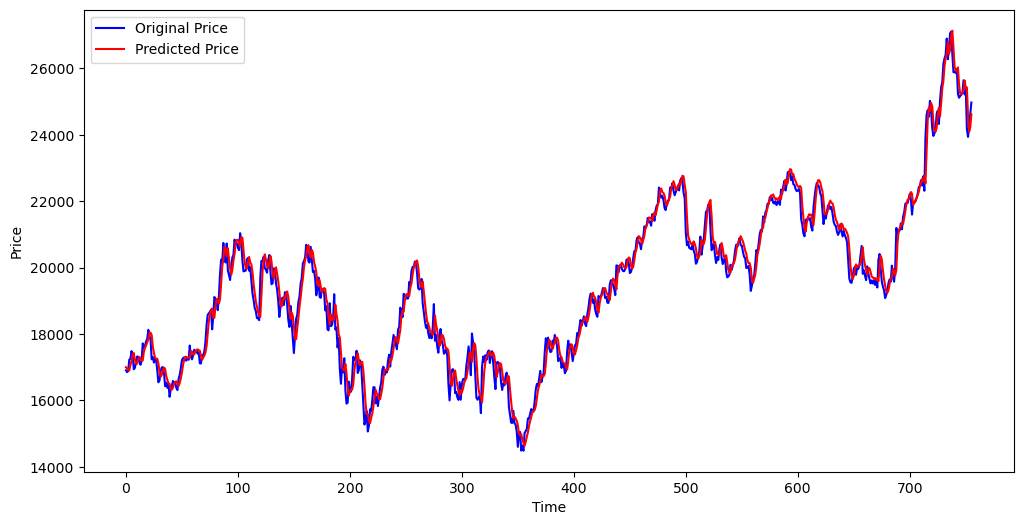

In [262]:
plt.figure(figsize=(12,6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
# plt.xlim(500, 700)
# plt.ylim(10, 25)
plt.show()

# 10. Model Evaluation

In [256]:
# MSE
mse = np.mean((y_test - y_predicted) ** 2)
mse

10.338830440773375

In [268]:
# RMSE
rmse = np.sqrt(mse)
rmse

369.5144130774152

In [267]:
# R-Squared
# Calculate SSR (Sum of Squared Residuals)
ssr = np.sum((y_test - y_predicted) ** 2)

# Calculate SST (Total Sum of Squares)
sst = np.sum((y_test - np.mean(y_test)) ** 2)

# Calculate R^2
r_squared = 1 - (ssr / sst)
r_squared

0.976737053421554

In [264]:
from sklearn.metrics import mean_squared_error, r2_score

In [265]:
mse = mean_squared_error(y_test, y_predicted)
print(f"Mean Squared Error (MSE): {mse}")

Mean Squared Error (MSE): 136540.90147194665


In [266]:
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 369.5144130774152


In [269]:
r2 = r2_score(y_test, y_predicted)
print(f"R-squared (R²): {r2}")

R-squared (R²): 0.976737053421554
